In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/processed/cleaned_accident_data.csv")
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,is_peak_hour,festival,risk_score,datetime,year,month,day,weekday,time_of_day,season
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,05:00:00,5,Sunday,1,...,0,Unknown,0.85,2023-10-22 05:00:00,2023,10,22,6,Morning,Post-Monsoon
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,04:00:00,4,Sunday,1,...,0,Unknown,0.10,2023-05-21 04:00:00,2023,5,21,6,Night,Summer
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00:00,13,Wednesday,0,...,0,Unknown,0.45,2024-07-10 13:00:00,2024,7,10,2,Afternoon,Monsoon
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00:00,11,Sunday,1,...,0,Unknown,0.65,2025-03-30 11:00:00,2025,3,30,6,Morning,Summer
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00:00,16,Thursday,0,...,0,Unknown,0.10,2024-01-25 16:00:00,2024,1,25,3,Afternoon,Winter


In [3]:
coords = df[['latitude', 'longitude']].dropna()
coords.shape

(20000, 2)

In [4]:
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

In [5]:
dbscan = DBSCAN(
    eps=0.3,        
    min_samples=15  

clusters = dbscan.fit_predict(coords_scaled)

In [6]:
coords['cluster'] = clusters
coords.head()

,latitude,longitude,cluster
0,18.680827,73.930388,0
1,18.817732,72.790846,0
2,19.096889,72.819424,0
3,30.787805,76.847507,1
4,12.965155,80.283313,2


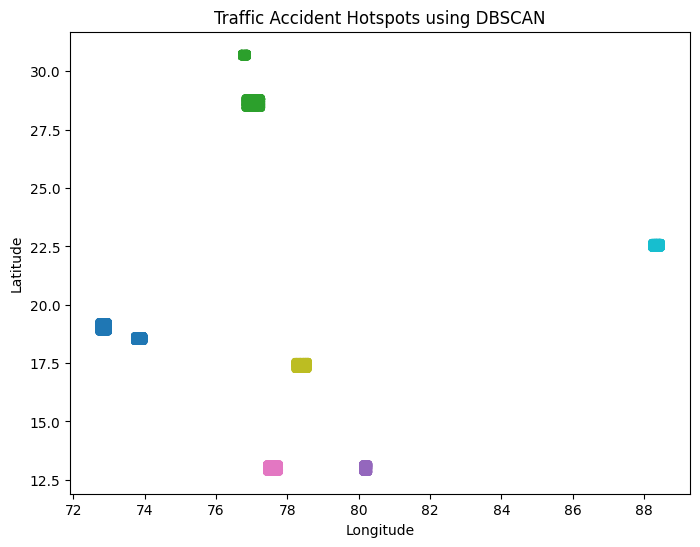

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(
    coords['longitude'],
    coords['latitude'],
    c=coords['cluster'],
    cmap='tab10',
    s=10
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Traffic Accident Hotspots using DBSCAN")
plt.show()

In [8]:
coords['is_hotspot'] = coords['cluster'].apply(lambda x: 0 if x == -1 else 1)
coords['is_hotspot'].value_counts()

is_hotspot
1    20000
Name: count, dtype: int64

In [9]:
df = df.loc[coords.index]
df['cluster'] = coords['cluster']
df['is_hotspot'] = coords['is_hotspot']

df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,risk_score,datetime,year,month,day,weekday,time_of_day,season,cluster,is_hotspot
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,05:00:00,5,Sunday,1,...,0.85,2023-10-22 05:00:00,2023,10,22,6,Morning,Post-Monsoon,0,1
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,04:00:00,4,Sunday,1,...,0.10,2023-05-21 04:00:00,2023,5,21,6,Night,Summer,0,1
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00:00,13,Wednesday,0,...,0.45,2024-07-10 13:00:00,2024,7,10,2,Afternoon,Monsoon,0,1
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00:00,11,Sunday,1,...,0.65,2025-03-30 11:00:00,2025,3,30,6,Morning,Summer,1,1
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00:00,16,Thursday,0,...,0.10,2024-01-25 16:00:00,2024,1,25,3,Afternoon,Winter,2,1


In [10]:
df.to_csv("../data/processed/hotspot_clustered_data.csv", index=False)